# Trabajo Fin de Máster  
### Análisis de la Ciudad mediante Aprendizaje Supervisado  
#### Detección Automática de Tipologías Residenciales y Patrones de Cerramiento: Interpretabilidad vs Rendimiento

**Master Universitario en Ciencia de Datos e Ingeniería de Computadores (Universidad de Granada)**

> **Autor:** David Fernández Martínez    
> **Email personal:** david.fernxndez.martinez@gmail.com  
> **Email académico:** davidfm8@correo.ugr.es  
> **LinkedIn:** [linkedin.com/in/david-fernández-martínez](https://www.linkedin.com/in/david-fern%C3%A1ndez-mart%C3%ADnez/)  
> **GitHub:** [github.com/davidfernxndez](https://github.com/davidfernxndez)

---

## Análisis de interpretabilidad: Modelos interpretables vs caja negra

### 📝 Descripción del notebook
TO COMPLETE...

# Configuración de entorno e *imports*

Este proyecto ha sido realizado en un entorno Anaconda con la versión 3.11.15 de *Python*. Las versiones de las librerias requeridas se encuentran en el fichero *requirements.txt*.

En esta sección se importan las librerias necesarias para la ejecución de este fichero jupyter notebook, se activa el *reload* de módulos externos y se configuran aspectos globales y de reproducibilidad.

In [1]:
# jupyter extensions to automatically reload external modules
%load_ext autoreload
%autoreload 2

In [3]:
import os
import warnings
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Configuration object
from src.config import cfg

# XAI visualization methods
from src.XAI_utils import (
    # MULTINOMIAL LOGISTIC REGRESSION METHODS
    load_lr_coefs,
    plot_lr_feature_importance,
    plot_lr_class_coefs,
    
    # DECISION TREE METHODS
    plot_tree_feature_importance,
    get_visual_decision_tree,
    get_leaf_classes_distribution,
    
    # SHAP
    get_shap_svm,
    get_shap_tree,
    plot_shap_global_feature_importance,
    plot_shap_class_dashboard
)

**Import troubleshooting**

If the `src` imports fail when running this notebook in a different environment,
uncomment and execute the following cell:

```python
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [4]:
# Global configuration
sns.set_theme(style="ticks", context="notebook")
plt.rcParams["font.family"] = "sans-serif"
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
warnings.filterwarnings("ignore")

In [5]:
# Set models folder
models_folder = os.path.join(cfg.OUTPUT_DIR, "models")

In [6]:
# Reproducibility
SEED = cfg.SEED 
np.random.seed(SEED)
random.seed(SEED)

# 1. Regresión Logística Multinomial (SoftMax Regression)

En primer lugar se cargan los coeficientes del modelo regresión logística multinomial almacenado en *output/models/Logistic_Regression_model.pkl*. Esta matriz contiene los coeficientes $\beta$ aprendidos por el modelo para cada variable predictora y clase. Las filas de la matriz representan cada una de las cinco categorías de la variable objetivo mientras que las columnas representan cada una de las $25$ variables predictoras consideradas en el modelo.

In [6]:
# Set pkl file path
LR_artifact_path =  os.path.join(models_folder,"Logistic_Regression_model.pkl")
LR_coef_df, LR_odds_df = load_lr_coefs(cfg, LR_artifact_path)

LR_coef_df

Logistic_Regression model successfully loaded from pkl file.
Coefficient matrix shape: (5, 25)


,CSS,CFS,CPE,LIN,LEX,DIS_1,DIS_2,DIS_3,VER,MUR,CAD,BOL,ARB,CPP,PVI,PBL,COM,COMS,PPU,PRE,PPR,GSE,CSE,BSE,ASE
Protegido,-2.620734,0.789259,-0.862114,-3.430467,-0.376423,-0.508542,-0.906209,1.155353,1.097056,-0.103533,-0.001543,0.138102,-0.738445,-1.049072,-3.978736,-6.309256,2.012325,1.324107,-4.110672,-0.284909,1.356499,1.669723,5.916887,2.567041,3.495756
Controlado,-1.276828,-0.988926,-0.308364,-3.095256,0.461351,-0.753318,-0.354230,1.455859,0.613997,1.549509,-0.261263,-0.733050,-0.138638,-0.284452,-3.367413,-0.763908,-0.178030,-0.657614,-1.984175,0.187643,-0.159928,-2.849423,-1.045214,0.593155,-1.561504
Autoaislado,5.100228,3.255703,2.476314,3.834809,0.438360,2.287055,2.983976,-5.969160,-0.508291,-0.303293,-0.008745,1.036344,0.019459,0.935249,1.171900,0.272633,0.236492,0.306366,4.774024,0.617170,2.229660,-0.745297,0.024166,-2.353654,-0.073399
Individualista,-1.126011,-0.726645,-0.252357,-1.202397,-0.872869,0.066560,-1.222180,1.301899,-0.357498,0.078146,0.387487,-0.665895,0.274038,0.747666,5.622134,6.897512,-0.487568,-0.477600,-2.524407,-0.312463,-0.324023,-0.148753,-5.014666,-0.546143,-0.840067
Simbólico,-0.076655,-2.329391,-1.053479,3.893311,0.349581,-1.091755,-0.501357,2.056049,-0.845263,-1.220829,-0.115936,0.224498,0.583586,-0.349391,0.552116,-0.096982,-1.583219,-0.495260,3.845230,-0.207442,-3.102208,2.073749,0.118828,-0.260399,-1.020786


Para determinar la importancia global de las variables en el modelo se ha calculado el valor absoluto medio de los coeficientes de las variables predictoras en las cinco clases. En el siguiente gráfico de barras se muestra el ranking de importancia de variables de acuerdo a este criterio.

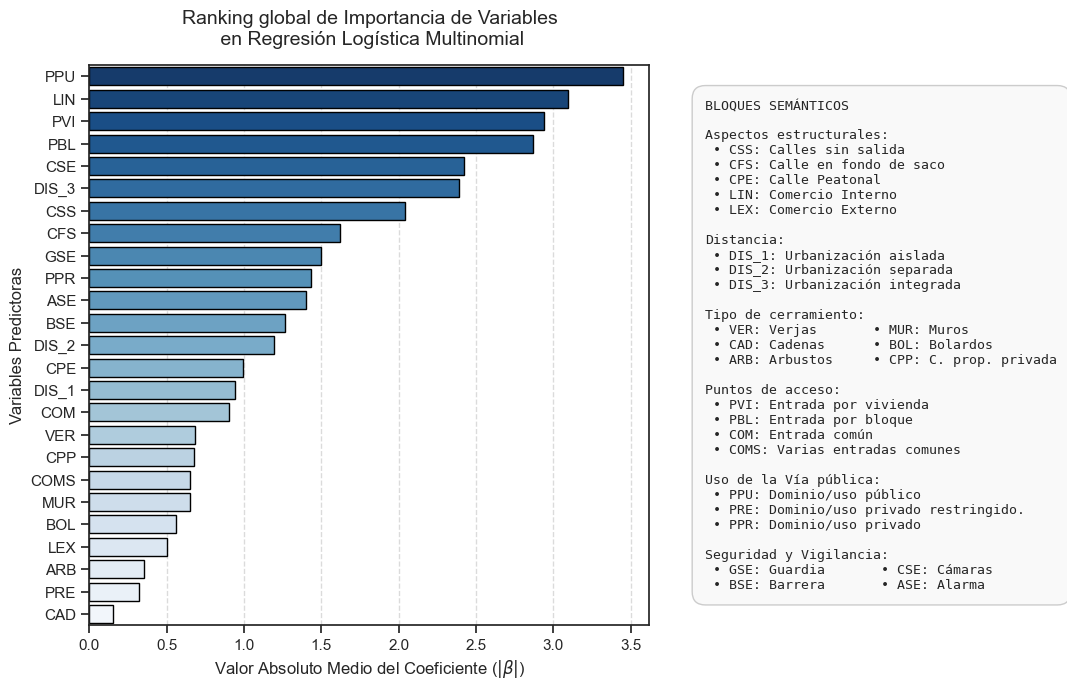

In [7]:
plot_lr_feature_importance(LR_coef_df, criterion="mean")

El análisis de importancia global de variables muestra que el modelo de regresión logística multinomial basa sus predicciones en variables pertenecientes a distintos bloques semánticos, lo que indica que la clasificación no depende de un único tipo de característica, sino que integra información morfológica urbana diversa.

La variable con mayor relevancia para el modelo es el uso y dominio público de la vía (**PPU**). El dominio privado y de uso privado (**PPR**) alcanza aproximadamente la mitad de la importancia de **PPU**, mientras que el uso privado con acceso público restringido (**PRE**) apenas influye al presentar coeficientes medios próximos a cero. Este muestra como el uso de la vía es relevante cuando su significado semántico está claramente definido, mediante un uso completamente público (**PPU**) o completamente privado (**PPR**).

La segunda variable más importante son los comercios internos (**LIN**), que pertenece al bloque de "Aspectos Estructurales". Otras variables de este bloque como las calles sin salida (**CSS**) y las calles en fondo de saco (**CFS**) presentan coeficientes medios elevados, mientras que los comercios externos (**LEX**) y las calles peatonales (**CPE**) se situan en la zona inferior del ranking.

En el bloque de tipo de acceso se destaca el acceso por vivienda (**PVI**) y por bloque (**PBL**) que ocupan la tercera y cuarta posición. Es destacable que para el modelo los tipos de acceso comunales (**COM** y **COMS**) tienen poca influencia, lo cual puede indicar que para el grado de cerramiento los accesos que implican mayor individualización son más discriminativos. 

El bloque de seguridad es el que presenta un mayor número de variables influyentes con coeficientes medios superiores a $1$. Lidera este bloque las cámaras de seguridad (**CSE**), no obstante el resto de elementos de seguridad presentan magnitudes relevantes lo que indica que el modelo utilia en conjunto todas estas variables para discriminar entre los distintos grados de cerramiento.

Al mismo nivel de importancia que **CSE** se encuentra la variable **DIS_3** que codifica que el complejo residencial se encuentra integrado en el casco urbano. Sin embargo, las variables **DIS_2** y **DIS_1** que codifican el resto de tipos de distancia tienen una importancia muy reducida.

Uno de los resultados más llamativos del análisis es la escasa relevancia de las variables pertenecientes al bloque Tipo de cerramiento, cuyos coeficientes medios permanecen por debajo de $0.5$. Desde una perspectiva urbanística, cabría esperar que estas características tuvieran una influencia más directa sobre la clasificación del grado de cerramiento. Sin embargo, el modelo parece apoyarse preferentemente en variables asociadas al tipo de acceso, seguridad, elementos viarios internos y tipo de uso de los mismos.

Analizar el signo y la magnitud de los coeficientes asociados a una determinada categoría de la variable objetivo permite definir el "perfil" que el modelo ha aprendido para esa categoría. Se denomina "perfil" al conjunto de variables que contribuyen de forma más significativa a aumentar o disminuir la probabilidad de pertenecer a una categoría concreta en comparación con el resto. Este conjunto de variables permite realizar una interpretación que define a la clase de acuerdo a las características que utiliza el modelo preferentemente para clasificarla.


Para realizar este estudio se ha desarrollado la función *plot_lr_class_coefs()*, que genera un diagrama de barras horizontal con los coeficientes de todas las variables para una clase específica. La escala de representación se mantiene constante entre todas las clases, definida por los valores mínimo y máximo globales de los coeficientes del modelo. 

Dado que las variables predictoras se estructuran en bloques semánticos, el gráfico organiza las variables por grupos y las ordena según la magnitud de sus coeficientes dentro del grupo. Esta visualización facilita la interpretación tanto a nivel de variable individual como a nivel del bloque semántico en conjunto.


A continuación, se analiza este gráfico de barras para cada uno de los cinco grados de cerramiento.

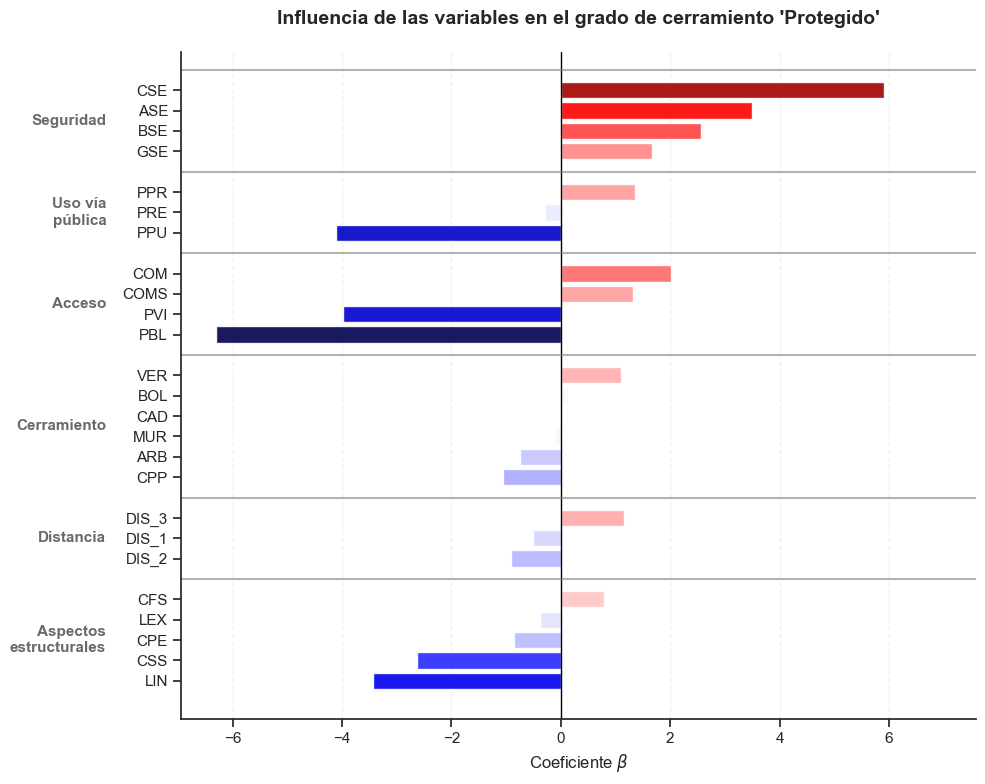

In [8]:
plot_lr_class_coefs(LR_coef_df, "Protegido")

El perfil aprendido por el modelo para identificar a la clase "Protegido" está claramente dominado por las variables del bloque semántico de seguridad, donde La presencia de cámaras de seguridad (**CSE**) destaca como el factor más influyente. En conjunto, estas variables actúan como catalizadores cuya presencia contribuye a que un complejo residencial sea clasificado como Protegido.

Los factores inhibidores del grado de cerramiento "Protegido" se distribuyen en varios bloques semánticos. Destacan principalmente los acceso por bloque (**PBL**) o por vivienda (**PVI**) junto al uso público de la vía (**PPU**). En menor medida, la presencia de elementos estrucurales internos como calles sin salida (**CSS**) o comercios internos (**LIN**) contribuyen a reducir la probabilidad de que el complejo residencial sea clasificado como "Protegido".


Puede interpretarse que el modelo caracteriza la clase “Protegido” como un tipo de complejo residencial fuertemente asociado a la presencia de servicios de seguridad y a la limitada existencia de espacios compartidos por no residentes. Esta configuración se refleja en la ausencia de comercios internos, la preferencia por el uso privado de la vía pública y el predominio de accesos comunales frente a accesos por vivienda o por bloque, lo que en conjunto reduce la permeabilidad y dificulta el tránsito de personas externas al complejo residencial.

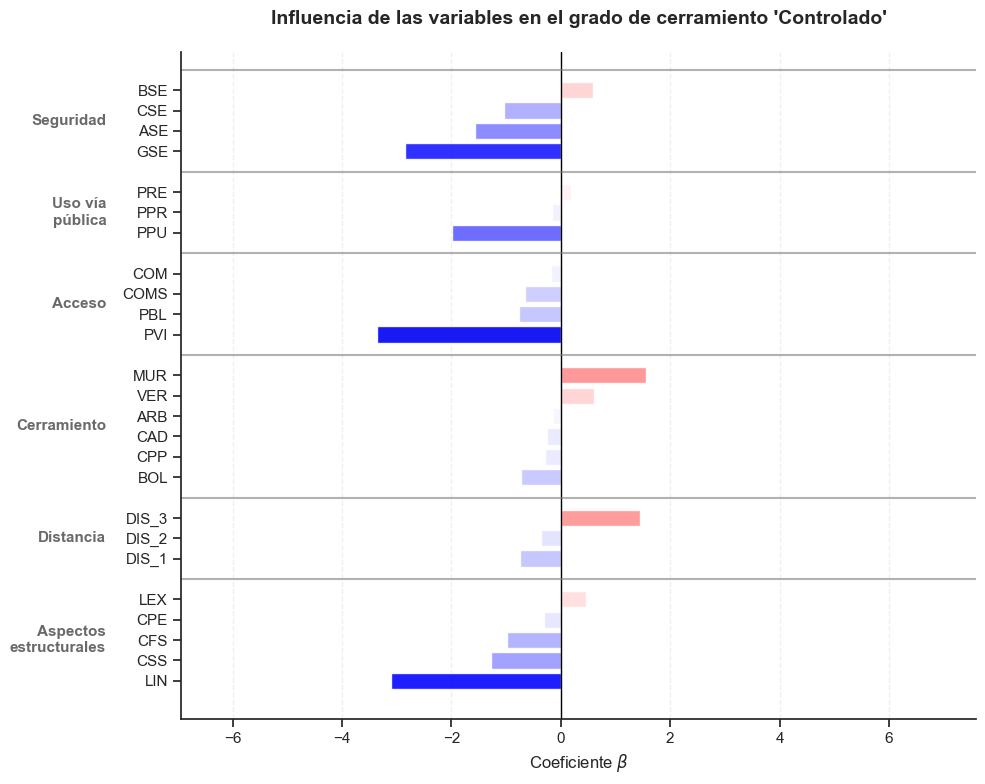

In [9]:
plot_lr_class_coefs(LR_coef_df, "Controlado")

Los coeficientes aprendidos por el modelo para la clase “Controlado” indican que esta categoría se caracteriza principalmente por la ausencia de variables, dado que los coeficientes de mayor magnitud en valor absoluto son negativos.

En este sentido, la presencia de comercios internos (**LIN**), acceso por vivienda (**PVI**) y uso público de la vía (**PPU**) actúan como factores inhibidores de la pertenencia a esta categoría. Este patrón es análogo a lo que ocurre en la categoría "Protegido". Sin embargo, en este caso la presencia de servicios de seguridad también contribuye a reducir la probabilidad de pertenecer a este grado de cerramiento.

En consecuencia, el modelo aprende que los complejos residenciales "Controlados" comparten con los "Protegidos" un patrón general de ausencia de determinadas características, pero se diferencian principalmente en el papel de las variables de seguridad, que actúan como factores catalizadores en la clase "Protegido" y como factores inhibidores en la clase "Controlado".

Puede interpretarse que para el modelo, los complejos residenciales "Controlados" presentan un patrón de ausencia de características muy similar al de los complejos "Protegidos" pero diferencia ambas categorías a través de los servicios de seguridad, que actuan como catalizadores del grado de cerramiento "Protegido" y como inhbidores del grado de cerramiento "Controlado".

Este análisis permite concluir que para el modelo de regresión logística la diferencia entre ambas categorías reside en la presencia de servicios de seguridad.

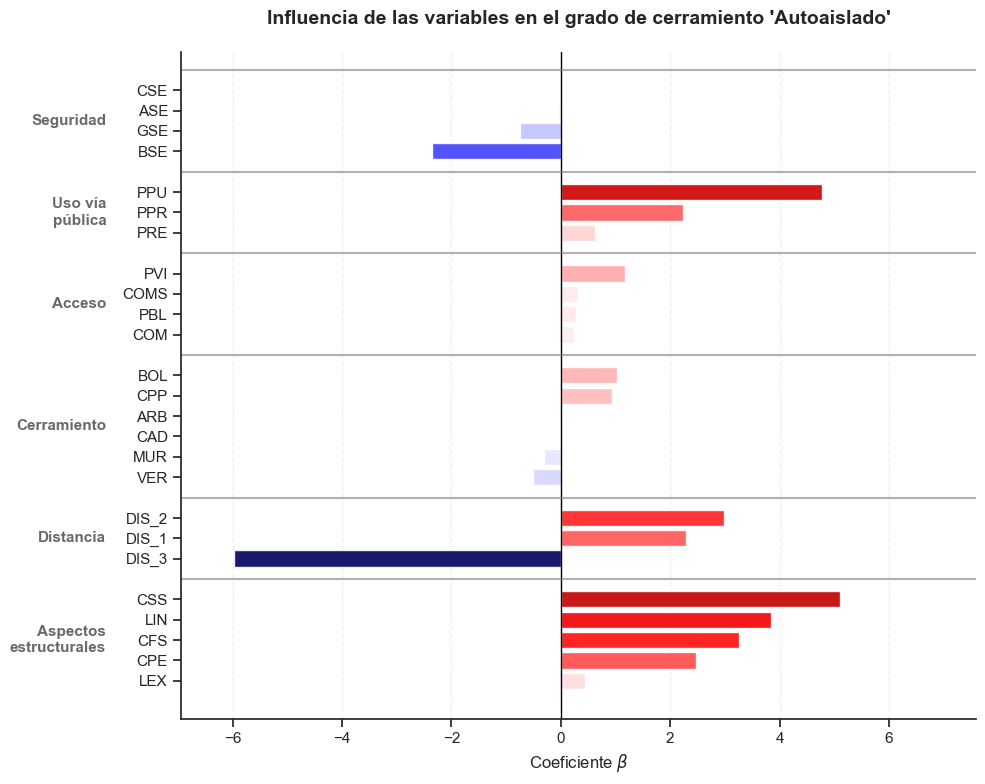

In [10]:
plot_lr_class_coefs(LR_coef_df, "Autoaislado")

En el grado de cerramiento “Autoaislado” se observa un patrón conformado por múltiples variables catalizadoras y una clara variable inhibidora que actúa como principal elemento discriminante de esta categoría.

El bloque semántico de aspectos estructurales se destaca como el principal catalizador de este grado de cerramiento. La presencia de vias internas como calles sin salida (**CSS**), calles en fondo de saco (**CFS**) y calles peatonales (**CPE**) junto a la presencia de comercios internos contribuyen a que un complejo residencial sea clasificado como "Autoaislado".

El principal factor inhibidor pertenece al bloque semántico de la distancia. La variable **DIS_3**, que codifica que el complejo residencial se encuentra integrado en el casco urbano, reduce notablemente las probabilidades del grado de cerramiento "Autoaislado". Este valor tan negativo del coeficiente de **DIS_3**, es coherente con lo observado en el análisis exploratorio, donde ningún complejo residencial "Autoaislado" del conjunto de datos tiene esta variable activa. Como consecuencia, el modelo de regresión logística obtiene un coeficiente negativo con un valor de magnitud absoluta muy alto.

Por lo tanto, las otras variables de distancia (**DIS_1** y **DIS_2**) se comportan como catalizadores. Estas variables indican que el complejo residencial está aislado o separado, respectivamente, del núcleo úrbano.

En relación con el uso de la vía pública, se observa que tanto el uso público (**PPU**) como el uso privado (**PPR**) contribuyen positivamente a la clasificación, aunque con distinta intensidad. Esto sugiere que, en este caso, la distinción entre ambos tipos de uso no resulta altamente discriminativa para este grado de cerramiento.

Puede concluirse que el modelo caracteriza el grado de cerramiento "Autoaislado" como un tipo de complejo residencial no integrado en el casco urbano, con presencia significativa de estructura viaria interna cuyo uso puede ser tanto público como privado.

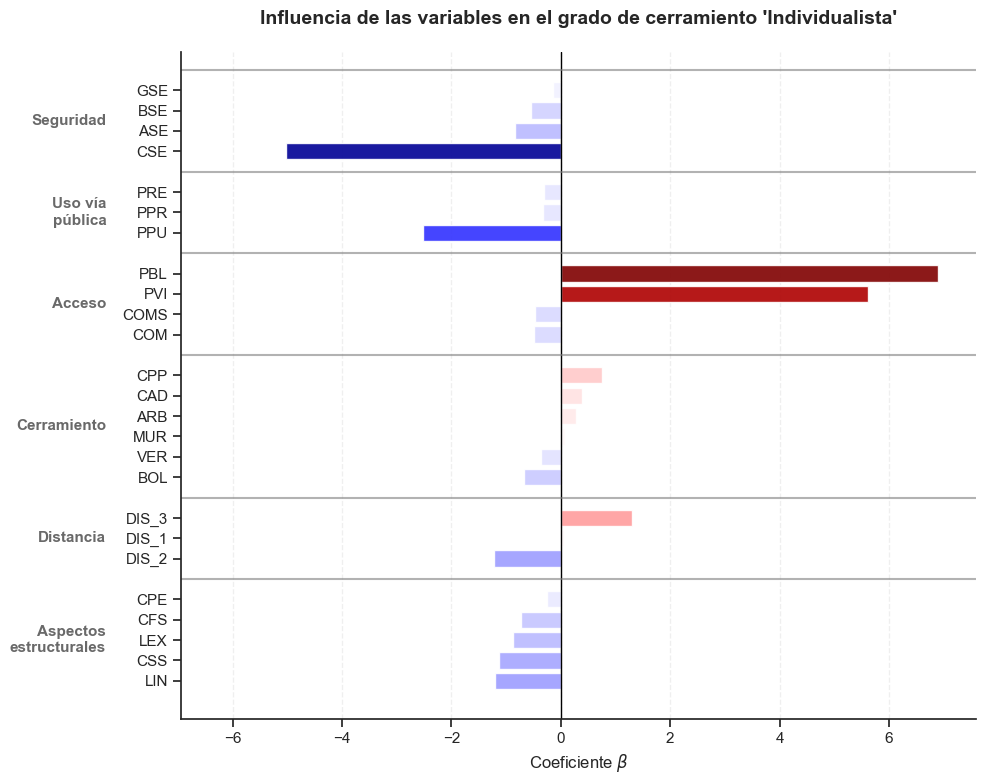

In [11]:
plot_lr_class_coefs(LR_coef_df, "Individualista")

La clase “Individualista” se caracteriza por un número reducido de variables que presentan una influencia claramente dominante frente al resto.

El modelo identifica como principales factores catalizadores los accesos por bloque (**PBL**) y por vivienda (**PVI**), que incrementan de forma significativa la probabilidad de pertenencia a esta categoría.En contraste, la ausencia de cámaras de seguridad (**CSE**) y el uso público de la vía (**PPU**) actúan como principales factores inhibidores. 

Ninguna de las variables asociadas al uso de la vía (**PPU**, **PPR** y **PRE**) presenta coeficientes positivos. Este resultado, junto con el hecho de que las variables del bloque de aspectos estructurales actúan como inhibidores con coeficientes de magnitud relativamente baja, sugiere que los complejos residenciales “Individualistas” tienden a presentar una escasa o nula estructuración viaria interna, lo que se traduce, de forma coherente, en una ausencia de usos asociados a dicha red viaria.

El resto de variables presentan coeficientes de magnitud reducida, lo que indica una capacidad explicativa limitada dentro de este grado de cerramiento. 

Este grado de cerramiento puede interpretarse como un tipo de complejo residencial caracterizado por un acceso individual o a través de bloque sin estructura viaria interna ni mecanismos de seguridad.

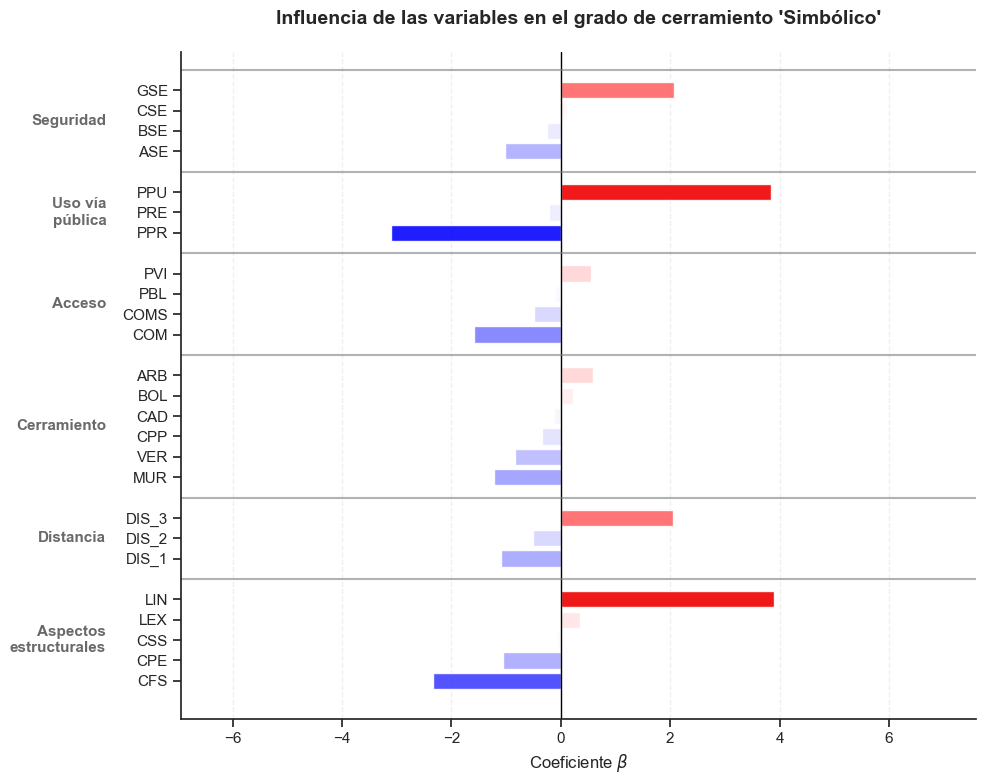

In [12]:
plot_lr_class_coefs(LR_coef_df, "Simbólico")

El perfil de los complejos residenciales "Simbólicos" aprendido por el modelo está fuertemente determinado por las variables asociadas al uso de la vía pública. En este sentido, el dominio y uso público (**PPU**) actúa como principal factor catalizador, mientras que el uso privado (**PPR**) presenta un efecto inhibidor de magnitud similar. Esto sugiere que la distinción entre ambos extremos del uso del espacio viario contribuye fuertemente a clasificar este grado de cerramiento.

Los comercios internos (**LIN**) se comportan como el otro gran factor catalizador. Sin embargo, las variables de calles internas presentan coeficientes negativos en este grado de cerramiento.

Por último, destaca que la presencia de guardias de seguridad (**GSE**) contribuya de forma positiva a la probabilidad de pertenencia al grado de cerramiento “Simbólico”, lo cual no se alinea completamente con el conocimiento urbanístico previo asociado a esta categoría, entendida como el nivel más sutil de cerramiento.

No obstante, debe tenerse en cuenta que esta clase presenta el rendimiento más bajo entre los modelos evaluados. En el caso de la regresión logística, su precisión es notablemente reducida, por lo que la interpretabilidad de los coeficientes debe considerarse con cautela, ya que podría estar reflejando patrones menos estables o menos representativos.

Bajo esta premisa, puede concluirse que el modelo caracteriza el grado de cerramiento “Simbólico” como complejos residenciales asociados a un uso predominantemente público de la vía, sin necesidad de una estructura viaria interna bien definida. Se trataría, por tanto, de entornos integrados en el casco urbano que pueden contar con la presencia de comercios internos.

El mecanismo de interpretabilidad que ofrece la regresión logística multinomial permite comprender de forma cuantitativa, transparente y directamente trazable cómo el modelo realiza la clasificación. A través de sus coeficientes es posible identificar qué variables dominan la asignación a cada categoría y en qué sentido lo hacen, distinguiendo entre efectos catalizadores e inhibidores en función del signo y la magnitud. Esto facilita la extracción de conocimiento interpretable y útil para el análisis urbanístico del problema, al permitir relacionar de forma explícita características urbanísticas con el grado de cerramiento.

# 2 Árbol de decisión

La interpretabilidad del árbol de decisión se apoya en los siguientes análisis:
* Análisis de la importancia de las variables.
* Análisis de las reglas de decisión que componen la estructura del árbol.

In [6]:
# Set pkl file path
DT_artifact_path =  os.path.join(models_folder,"Decision_Tree_model.pkl")

## 2.1 Importancia de variables

En esta seccion se analiza la importancia de las variables, medida como la reducción de impureza acumulada que proporciona la variable en todas las particiones del árbol en las que participa.

A continuación se muestra un gráfico de barras que representa el ranking de importancia de variables de acuerdo a este criterio.

Decision_Tree model successfully loaded from pkl file.


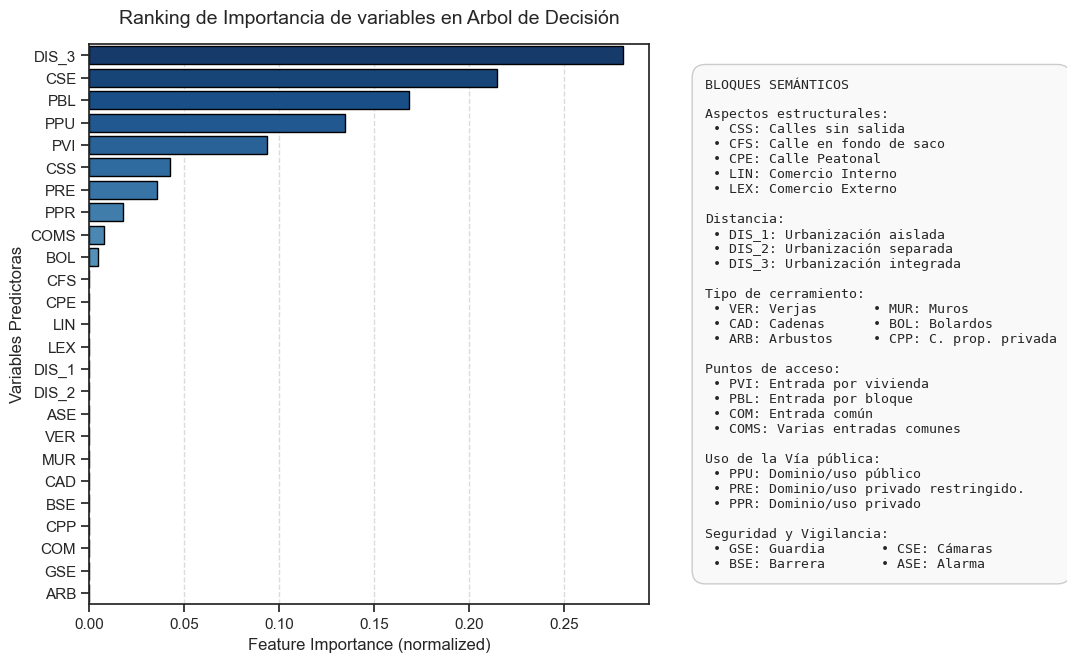

In [7]:
plot_tree_feature_importance(cfg, DT_artifact_path)

El gráfico de importancia de variables muestra que el árbol de decisión utiliza únicamente $10$ de las $25$ variables predictoras disponibles para realizar la clasificación. El árbol de decisión realiza una selección implícita de características, empleando únicamente aquellas variables que aportan la mayor capacidad discriminativa en las particiones del espacio de características, lo que contribuye a mejorar la interpretabilidad del modelo.

La variable con mayor importancia en la partición del espacio de características es **DIS_3**, que representa la integración del complejo residencial dentro del núcleo urbano. A continuación, le siguen las cámaras de seguridad (**CSE**), al acceso por bloque (**PBL**) y al uso público de la vía (**PPU**).

De forma conjunta, los bloques de variables más relevantes para el árbol de decisión corresponden al tipo de acceso y al uso de la vía pública. En el bloque de tipo de acceso, el modelo utiliza $3$ de las $4$ variables disponibles, destacando principalmente el acceso por bloque (**PBL**) y el acceso por vivienda (**PVI**). En el bloque de uso de la vía pública, las tres variables disponibles (**PPU**, **PPR** y **PRE**) participan en las particiones del árbol, destacando con mayor importancia el uso público de la vía (**PPU**).

En conjunto, estos resultados indican que el árbol de decisión basa principalmente su capacidad de clasificación en cuatro dimensiones: la integración en el núcleo urbano, la presencia de cámaras de seguridad, el tipo de acceso y el uso de la vía.

Este análisis revela que la información utilizada por el árbol de decisión para clasificar el grado de cerramiento de los complejos residenciales reside en cuatro aspectos: la integración en el núcleo úrbano, presencia de cámaras de seguridad, tipo de acceso y el uso de la vía pública.

Comparándo este analisis de importancia de variables, con el realizado en la sección anterior para el modelo de regresión logística, se observa que ambos modelos identifican como relevantes variables comunes como **PVI**, **PBL**, **PPU** y **DIS_3**. No obstante, existen discrepancias notables. La variable **DIS_3** es claramente dominante en el árbol de decisión, mientras que en la regresión logística ocupa una posición intermedia dentro del ranking de importancia. Otro caso destacada es la variable de comercios internos (**LIN**), que se sitúa como la segunda variable más importante para el modelo de regresión logística pero el árbol de decisión no la utiliza en ninguna de sus particiones.

Estas diferencias se explican por la naturaleza del criterio de importancia en cada modelo. Mientras que el árbol prioriza variables con poder discriminativo localizado, la regresión logística valora contribuciones globales dentro de un modelo lineal.

El criterio de reducción de impureza del árbol le lleva a una selección ímplicita de características. Una variable solo se incorpora si produce mejoras significativas en alguna partición concreta, y puede ser descartada si su información resulta redundante respecto a otras variables ya seleccionadas. Esto otorga al árbol de decisión una interpretabilidad más directa al utilizar un subcojunto reducido de variables.

Un ejemplo representativo de este comportamiento se observa en el bloque semántico de servicios de seguridad. Ambos modelos identifican este bloque relevante para la clasificación. Sin embargo, el árbol de decisión selecciona únicamente la variable de cámaras de seguridad (**CSE**), mientras que en la regresión logístca el resto de servicios de seguridad (**ASE**, **GSE** y **BSE**) presentan coeficientes con una magnitud elevada y que actuan en conjunto como catalizadores o inhibidores de determinados grados de cerramiento.

El árbol de decisión simplifica la representación del problema al centrarse únicamente en la variable de seguridad con mayor capacidad discriminativa, lo que facilita la interpretación de las reglas generadas. Sin embargo, esta simplificación puede reducir la capacidad de generalización del modelo. Por ejemplo, un complejo residencial que no disponga de cámaras de seguridad, pero sí de otros elementos de seguridad, podría no ser clasificado correctamente por el árbol.

En cambio, la regresión logística proporciona una representación más densa del problema, ya que incorpora simultáneamente todas las variables en el proceso de decisión. Aunque esto incrementa la complejidad interpretativa del modelo, le permite conseguir un mejor rendimiento en los casos que no se adecuan a los patrones más generales.

Esto pone de manifiesto el compromiso existente entre rendimiento  e interpretabilidad, incluso entre modelos inherentemente transparentes. En la evaluación de rendimiento se ha observado que el modelo de regresión logística presenta un desempeño superior al árbol de decisión. Este análisis de interpretabilidad permite comprender en mayor profundidad el posible origen de estas diferencias, mostrando el equilibrio entre diferentes mecanismos de interpretabilidad y la capacidad predictiva de los modelos.

## 2.2 Análisis de las reglas de decisión

Para visualizar la estructura del árbol de decisión se utiliza la función *get_visual_decision_tree()*, desarrollada en el módulo *src/XAI_utils.py*, que emplea la librería *dtreeviz*. Para generar la visualización es necesario tener instalado el software graphviz y añadirlo al PATH del sistema.

La representación gráfica muestra la distribución de las categorías de la variable objetivo en cada partición mediante gráficos de barras, mientras que en las hojas finales se utiliza un Pie Chart para representar la distribución de clases. Además, se ha asignado un identificador numérico a cada hoja con el fin de facilitar la referencia durante el análisis de las reglas.

La estructura del árbol se ha almacenado en formato imagen en el directorio *images/*.

In [9]:
# Uncomment to update SVG file (images/viz_tree.svg)
# Graphviz software is required
#viz_tree = get_visual_decision_tree(cfg, DT_artifact_path)

<img src="../images/ARBOL_DE_DECISION_DTREEVIZ.jpg" alt="Estructura del árbol de decisión" width="90%">

Tal y como puede observarse en la estructura del árbol, el modelo genera un total de $15$ hojas terminales, lo que implica la existencia de $15$ reglas de decisión para realizar la clasificación. La longitud máxima de estas reglas es de $6$ variables, ya que la profundidad máxima del árbol se ha configurado con dicho valor durante el experimento. Esta restricción permite controlar la complejidad del modelo y mantener su interpretabilidad.

Con el objetivo de facilitar el análisis de las reglas, en la siguiente tabla se muestra la distribución de clases en cada una de las hojas terminales asociadas. Esto permite cuantificar el grado de fiabilidad de las reglas de decisión respecto a la clase dominante en dicha hoja.

In [11]:
leaf_df = get_leaf_classes_distribution(cfg, DT_artifact_path)

Decision_Tree model successfully loaded from pkl file.


Leaf_ID,Total_Muestras,Protegido (%),Controlado (%),Autoaislado (%),Individualista (%),Simbólico (%),Clase dominante
1,17,18.26,65.08,0.00,0.00,16.65,Controlado
2,7,0.00,24.61,0.00,75.39,0.00,Individualista
3,7,53.33,3.17,43.50,0.00,0.00,Protegido
4,33,0.00,0.00,0.00,91.08,8.92,Individualista
5,6,0.00,0.00,52.85,47.15,0.00,Autoaislado
6,14,0.00,0.00,95.88,0.00,4.12,Autoaislado
7,22,0.00,0.00,100.00,0.00,0.00,Autoaislado
8,239,4.56,81.59,0.00,0.00,13.86,Controlado
9,9,0.00,0.00,0.00,0.00,100.00,Simbólico
10,72,0.00,0.00,0.00,91.79,8.21,Individualista


A continuación, se extrae y analiza el conjunto de reglas asociado a cada grado de cerramiento. Para facilitar su identificación, cada regla se referencia mediante el identificador de la hoja correspondiente, lo que permite localizar el camino seguido desde la raíz hasta el nodo terminal y la distribución de clases mostrada en la tabla.

El grado de cerramiento "Protegido" queda definido a través de dos reglas de decisión:
* **Regla ID=14.** $(DIS\_3 = 1 \land CSE = 1 \land PBL = 0) \implies \text{Protegido}$
* **Regla ID=3.** $(DIS\_3 = 0 \land CSS = 0 \land PPU = 0 \land PVI=0 \land PPR=1) \implies \text{Protegido}$

La regla $14$ presenta la mayor fiabilidad, ya que el $83.72\%$ de las muestras clasificadas en esta hoja pertenecen a la clase "Protegido". Además, se trata de una regla relativamente simple, compuesta únicamente por tres variables. Su interpretación semántica sugiere que los complejos residenciales protegidos suelen estar integrados en el núcleo urbano, disponer de cámaras de seguridad y no presentar acceso por bloque.

En cambio, la regla $3$ muestra una menor capacidad discriminativa, al coexistir en la hoja muestras de las clases "Protegido" y "Autoaislado" en proporciones similares. Esta regla describe complejos no integrados en el núcleo urbano, sin calles sin salida, sin acceso por vivienda y con uso viario privado. 

En conjunto, ambas reglas reflejan patrones asociados a un grado de cerramiento elevado, especialmente a través del uso de cámaras de seguridad (**CSE**) y mediante la privatización del espacio vario (**PPR**).

El grado de cerramiento "Controlado" se define mediante de tres reglas de decisión:
* **Regla ID=15.** $(DIS\_3 = 1 \land CSE = 1 \land PBL = 1) \implies \text{Controlado}$
* **Regla ID=8.** $(DIS\_3 = 1 \land CSE = 0 \land PPU = 0 \land PVI=0 \land PBL=0 \land PRE=0) \implies \text{Controlado}$
* **Regla ID=1.** $(DIS\_3 = 0 \land CSS = 0 \land PPU = 0 \land PVI=0 \land PBL=0 \land PPR=0 \land PBL=0) \implies \text{Controlado}$

En las tres hojas terminales la clase "Controlado" es dominante, lo que indica que este grado de cerramiento queda representado de forma consistente por el árbol de decisión.

La regla $15$ describe complejos residenciales integrados en el casco urbano, con cámaras de seguridad y acceso por bloque. La variable **PBL** constituye el principal elemento diferenciador respecto a la regla $14$ asociada al grado "Protegido".  El árbol distingue ambas categorías a partir del tipo de acceso: mientras que en el grado "Protegido" no existe acceso por bloque, en el grado "Controlado" este elemento reduce parcialmente la intensidad del cerramiento pese a mantener mecanismos de vigilancia como las cámaras de seguridad.

La regla $8$ representa el patrón más general dentro de esta categoría al concentrar el mayor número de muestras clasificadas como "Controlado". Esta regla agrupa complejos integrados en el casco urbano que no disponen de cámaras de seguridad (**CSE**) ni presentan acceso por vivienda (**PVI**) o por bloque (**PBL**), además de carecer de uso público (**PPU**) o público restringido (**PRE**) de la vía.

Por su parte, la regla $1$ describe complejos no integrados en el casco urbano, sin calles sin salida (**CSS**) y sin accesos por vivienda (**PVI**) o bloque (**PBL**). Además, no presentan uso público de la vía ni uso privado lo que sugiere que puedan carecer de estructura viaria interna. 

En conjunto el grado de cerramiento "Controlado" puede interpretarse como un nivel de cerramiento elevado pero que presenta al menos un elemento que suaviza dicha intensidad como la ausencia de cámaras de seguridad o el tipo de acceso por bloque.

El grado de cerramiento "Autoaislado" se define a través de tres reglas de decisión:
* **Regla ID=7.** $(DIS\_3 = 0 \land CSS = 1) \implies \text{Autoaislado}$
* **Regla ID=6.** $(DIS\_3 = 0 \land CSS = 0 \land PPU = 1) \implies \text{Autoaislado}$
* **Regla ID=5.** $(DIS\_3 = 0 \land CSS = 0 \land PPU = 0 \land PVI=0 \land COMS=1) \implies \text{Autoaislado}$

Las reglas $7$ y $6$ presentan una clara dominancia de la clase "Autoaislado", mientras que en la regla $5$ coexisten muestras de las categorías "Autoaislado" e "Individualista" en proporciones similares, lo que indica una menor capacidad discriminativa.

La variable **DIS_3**, utilizada en la primera partición del árbol, resulta especialmente relevante para esta categoría, ya que agrupa completamente a los complejos residenciales "Autoaislados". Este comportamiento es coherente con el análisis exploratorio previo, donde se observó que no existen complejos de este tipo integrados en el núcleo urbano $(DIS_3 = 1)$.

Las reglas $7$ y $6$ describen configuraciones relativamente simples: complejos residenciales situados fuera del núcleo urbano que presentan algún elemento asociado al uso compartido del espacio. En la regla $7$, dicho comportamiento se relaciona con la presencia de calles sin salida (**CSS**), mientras que en la regla $6$ aparece asociado al uso público de la vía (**PPU**).

La regla $5$ recoge un subconjunto más reducido de complejos residenciales que, no tienen calles sin salida ni uso público de la vía, pero presentan un tipo de acceso basado en varias entradas comunes (**COMS**).

En conjunto, las reglas muestran que el grado de cerramiento "Autoaislado" se caracteriza principalmente por la ausencia de integración en el núcleo urbano y por la existencia de elementos asociados al uso compartido del espacio residencial. Este último aspecto resulta especialmente relevante para diferenciar esta categoría de otros grados de cerramiento cuyas reglas también incluyen complejos residenciales situados fuera del núcleo úrbano.

Las reglas $3$ y $1$ correspondientes a las categorías "Protegido" y "Controlado", respectivamente, describen complejos residenciales no integrados en el casco urbano, pero en esos casos el espacio residencial no cuenta con elementos compartidos o su uso es privado.

Este análisis revela que los complejos residenciales "Autoaislados" son accesibles para no residentes y su cerramiento queda definido a través de su situación geográfica y la presencia de elementos disuasorios para no residentes, como calles sin salida. 

El grado de cerramiento "Individualista" queda definido mediante cinco reglas de decisión. Las dos primeras pertenecen a la rama izquierda del árbol y, por tanto, describen complejos residenciales no integrados en el núcleo urbano $(DIS_3 = 0)$:

* **Regla ID=2.** $(DIS\_3 = 0 \land CSS = 0 \land PPU = 0 \land PVI=0 \land PPR=0 \land PBL=1) \implies \text{Individualista}$
* **Regla ID=4.** $(DIS\_3 = 0 \land CSS = 0 \land PPU = 0 \land PVI=1 \land COMS=0) \implies \text{Individualista}$

Ambas reglas pueden interpretarse de forma conjunta puesto que el factor diferencial reside en el tipo de acceso. Los complejos residenciales que no están integrados en el núcleo úrbano son clasificados como "Individualistas" si no tienen uso de la vía pública (**PPU**) ni calles sin salida (**CSS**) pero acceden a través de bloque (**PBL**) o a través de vivienda (**PVI**).

En la rama derecha del árbol, los complejos residenciales integrados en el núcleo urbano $(DIS_3 = 1)$ quedan definidos mediante tres reglas adicionales:
* **Regla ID=12.** $(DIS\_3 = 1 \land CSE = 0 \land PPU = 0 \land PVI=1) \implies \text{Individualista}$
* **Regla ID=10.** $(DIS\_3 = 1 \land CSE = 0 \land PPU = 0 \land PVI=0 \land PBL=1 \land BOL=0) \implies \text{Individualista}$
* **Regla ID=11.** $(DIS\_3 = 1 \land CSE = 0 \land PPU = 0 \land PVI=0 \land PBL=1 \land PBL=1) \implies \text{Individualista}$

La interpretación de estas reglas es prácticamente equivalente a la observada en la rama izquierda, lo que indica que la variable **DIS_3** no resulta especialmente discriminativa para esta categoría. De nuevo, la clasificación depende del tipo de acceso y se añade la ausencia de cámaras de seguridad. De este modo, los complejos residenciales integrados en el núcleo urbano son clasificados como "Individualistas" cuando no disponen de cámaras de seguridad (**CSE**), no presentan uso público de la vía (**PPU**) y el acceso se realiza por vivienda (**PVI**) o por bloque (**PBL**).

Además, las reglas $10$ y $11$ evidencian una partición redundante del árbol, ya que la variable bolardos (BOL) no modifica la clase dominante en ninguna de las dos hojas terminales.

Aunque este grado de cerramiento cuenta con cinco reglas de decisión su interpretación se reduce esencialmente al tipo de acceso por vivienda o por bloque. En los complejos residenciales "Individualistas" el mecanismo de cerramiento consiste en accesos individuales acompañados de ausencia de uso público del viario.

Finalmente, el grado de cerramiento "Simbólico" queda definido mediante dos reglas de decisión:
* **Regla ID=13.** $(DIS\_3 = 1 \land CSE = 0 \land PPU = 1) \implies \text{Simbólico}$
* **Regla ID=9.**  $(DIS\_3 = 1 \land CSE = 0 \land PPU = 0 \land PVI=0 \land PBL=0 \land PRE=1) \implies \text{Simbólico}$

Las hojas terminales asociadas a ambas reglas son completamente puras, ya que únicamente contienen complejos residenciales clasificados como "Simbólico". Esto proporciona una elevada fiabilidad interpretativa a estas reglas.

Las dos reglas comparten una misma estructura basada en la integración en el núcleo urbano y la ausencia de cámaras de seguridad. La diferencia entre ambas reside en el tipo de uso del espacio viario. La regla $13$, que representa el caso más frecuente, describe complejos con uso público de la vía (**PPU**), mientras que la regla $9$ recoge complejos con uso público restringido (**PRE**) siempre y cuando el tipo de acceso no sea por vivienda (**PVI**) ni por bloque (**PBL**). 

Desde una perspectiva urbanística, estas reglas reflejan un grado de cerramiento débil lo cual resulta coherente con la propia naturaleza de la categoría "Simbólico", que constituye el grado de cerramiento más sútil y difuminado.

La clase "Simbólico" ha resultado la más dificil de clasificar para los modelos. El árbol de decision tiene un recall bajo, sin embargo mantiene un valor elevado de la precision. Esto se ve reflejado en reglas de decisión con hojas puras que hacen que el análisis interpretativo sea fiable. En cambio, en el modelo de regresión logística la precision de esta categoría es más baja y por tanto su interpretabilidad es menos robusta.

No obstante, el *recall* es en regresión logística es notablemente más alto por lo que su rendimiento global en esta clase será superior. Esto muestra de nuevo el compromiso existente entre rendimiento e interpretabilidad en función del objetivo de estudio.

La interpretabilidad del árbol de decisión constituye una ventaja relevante en términos de simplicidad explicativa. La selección implícita de variables que realiza el modelo reduce la complejidad del análisis al concentrarse en un subconjunto acotado de predictores. En este caso, este mecanismo permite identificar con claridad los bloques semánticos más influyentes en la clasificación, así como las variables específicas dentro de cada bloque con mayor relevancia. En particular, dentro del bloque de seguridad se observa que las cámaras de seguridad constituyen la variable más determinante, mientras que en el bloque de distancia únicamente se utiliza **DIS_3**, lo que simplifica la interpretación a la distinción entre integración o no integración en el núcleo urbano.

Este comportamiento contrasta con el observado en la regresión logística, donde múltiples variables dentro de un mismo bloque semántico pueden adquirir relevancias distintas en función del grado de cerramiento. En el árbol de decisión, todos los grados de cerramiento se describen a partir del mismo espacio características lo que permite una explicabilidad más homogénea de la clasificación.

No obstante, esta ganancia en interpretabilidad mediante reglas más simples y estructuradas conlleva una reducción en el rendimiento predictivo frente a otros modelos más flexibles. Aunque estas reglas son especialmente útiles para capturar patrones generales y caracterizar los grados de cerramiento con un número reducido de variables, la modelización de casos más heterogéneos o alejados de los patrones dominantes requiere enfoques con mayor capacidad de generalización.

# 3. Modelos caja negra

## 3.1 SVM

In [10]:
SVM_artifact_path =  os.path.join(models_folder,"SVM_model.pkl")

# Uncomment to recalculate shap values for SVM 
# The values has been stored in output/SHAP_global/SVM_shap_global.npy to avoid SHAP calculation time (approx 5 minutes)

#shap_values_SVM = get_shap_svm(cfg, SVM_artifact_path)

In [11]:
shap_values_SVM = np.load("../output/SHAP_global/SVM_shap_global.npy")

## 3.2 Random Forest

In [13]:
RF_artifact_path =  os.path.join(models_folder,"Random_Forest_model.pkl")
shap_values_RF = get_shap_tree(cfg, RF_artifact_path)

Random_Forest model successfully loaded from pkl file.
Get shap values with KernelExplainer...
Shap values calculated succesfully.
Array size: (642, 25, 5)

Saving results...
Output directory: C:\Users\david\Documents\MASTER_CIENCIA_DE_DATOS\TFM\PROJECT\output\SHAP_global


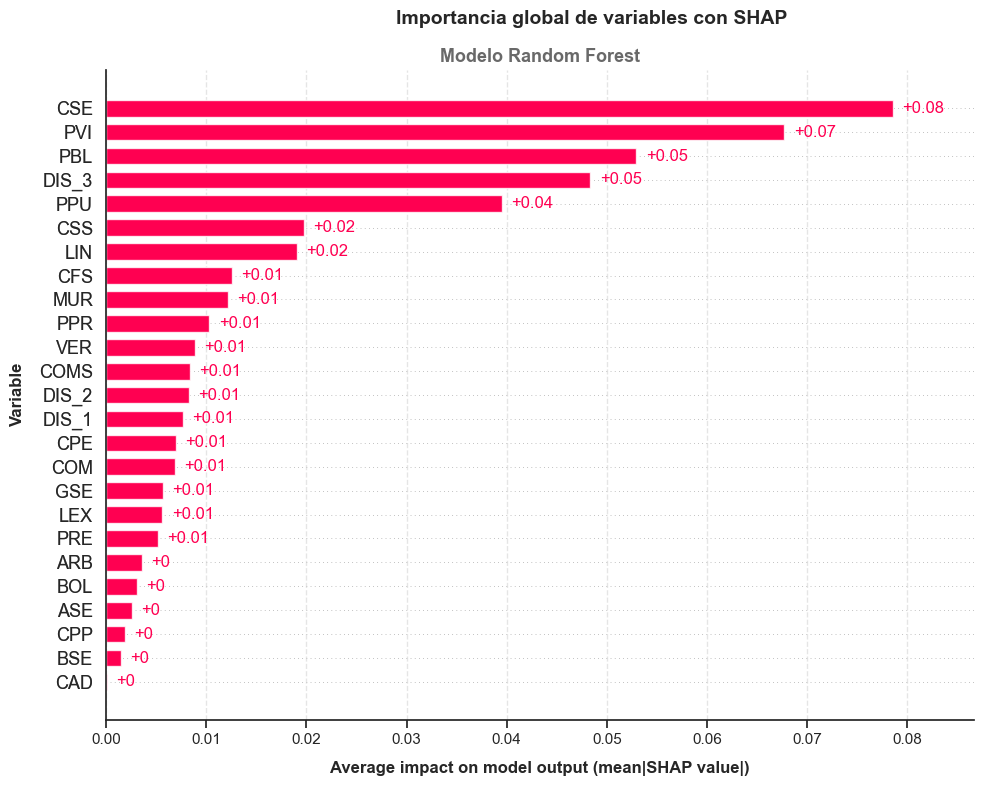

In [14]:
plot_shap_global_feature_importance(cfg, shap_values_RF, model_name="Random Forest", num_features_display=25)

## 3.1 XGBoost

In [7]:
XG_artifact_path =  os.path.join(models_folder,"XGBoost_model.pkl")
shap_values_XG = get_shap_tree(cfg, XG_artifact_path)

XGBoost model successfully loaded from pkl file.
Get shap values with KernelExplainer...
Shap values calculated succesfully.
Array size: (642, 25, 5)

Saving results...
Output directory: C:\Users\david\Documents\MASTER_CIENCIA_DE_DATOS\TFM\PROJECT\output\SHAP_global


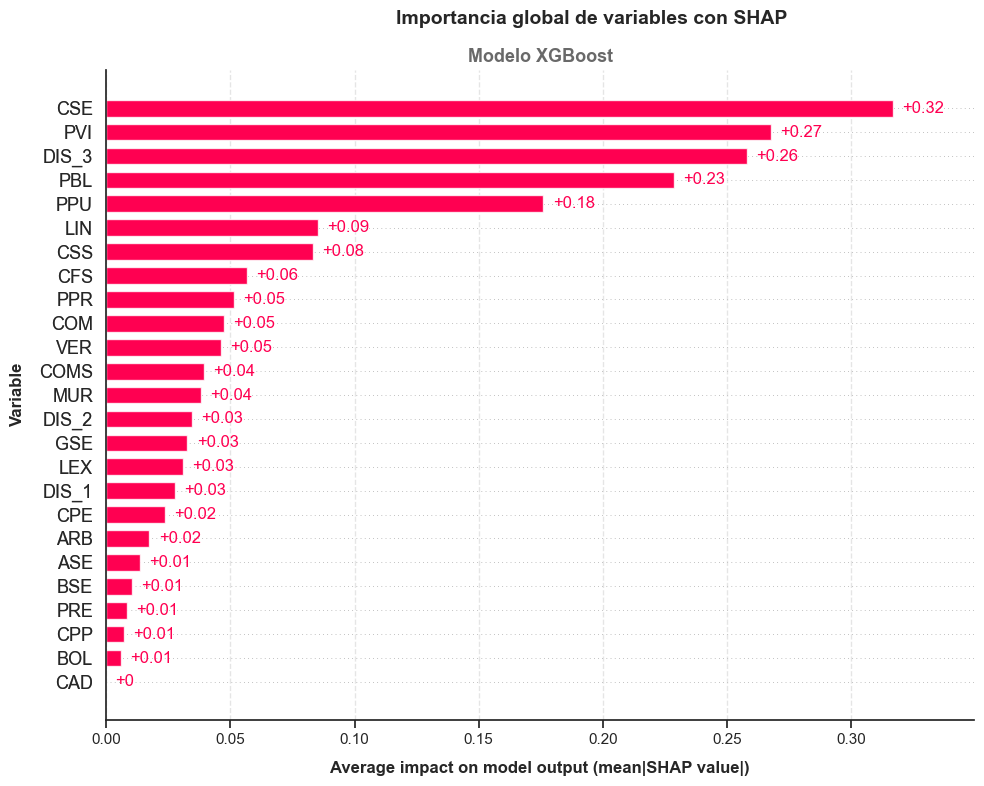

In [8]:
plot_shap_global_feature_importance(cfg, shap_values_XG, model_name="XGBoost", num_features_display=25)

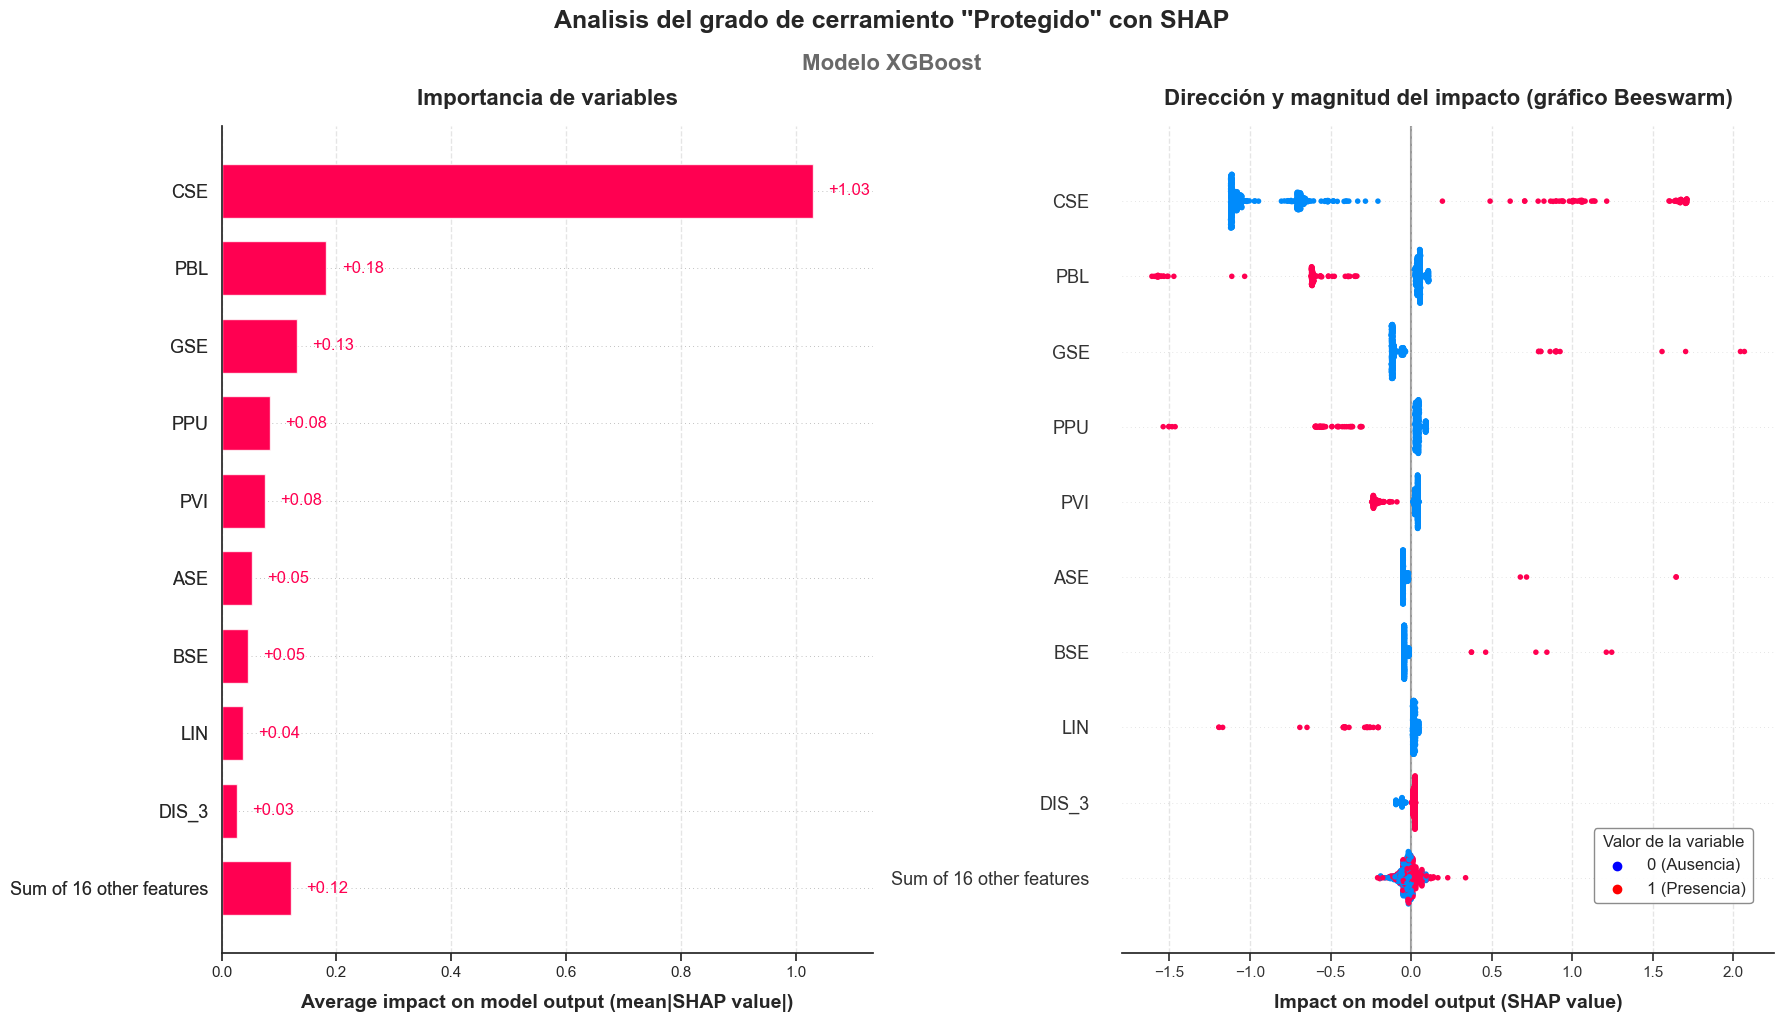

In [9]:
plot_shap_class_dashboard(cfg, shap_values_XG, class_label="Protegido", model_name="XGBoost", num_features_display=10)